## Importing the necessary libraries:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the datases from kaggle

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Unemployment_Rate_upto_11_2020.csv"
file_path1 = 'Unemployment in India.csv'

# Load the latest version
#unemployment_rate
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gokulrajkmv/unemployment-in-india",
  file_path,
)

#unemployment_in_india
df1 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gokulrajkmv/unemployment-in-india",
  file_path1,
)




/tmp/ipykernel_1641/1473415135.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unemployment-in-india' dataset.


/tmp/ipykernel_1641/1473415135.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df1 = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unemployment-in-india' dataset.


In [ ]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [ ]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Cleaning the data:

In [ ]:
df = df.dropna(how="all")
df1 = df1.dropna(how="all")

df = df.drop_duplicates()
df1 = df1.drop_duplicates()

df.columns = df.columns.str.strip()
df1.columns = df1.columns.str.strip()

df = df.drop(labels="Frequency", axis=1)
df1 = df1.drop(labels="Frequency", axis=1)

dummie = list(df.columns)
dummie[5] = 'Location'
df.columns = dummie

In [ ]:
df.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Location,longitude,latitude
0,Andhra Pradesh,31-01-2020,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,17.43,12988845,36.46,South,15.9129,79.74


In [ ]:
df1.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,5.17,12256762.0,44.68,Rural


In [ ]:
list_to_keep = ['Date', 'Estimated Unemployment Rate (%)', 'Region']

unemployement_in_india = pd.concat([df[list_to_keep], df1[list_to_keep]], ignore_index=True)

unemployement_in_india.head()

,Date,Estimated Unemployment Rate (%),Region
0,31-01-2020,5.48,Andhra Pradesh
1,29-02-2020,5.83,Andhra Pradesh
2,31-03-2020,5.79,Andhra Pradesh
3,30-04-2020,20.51,Andhra Pradesh
4,31-05-2020,17.43,Andhra Pradesh


## Visualising patterns:

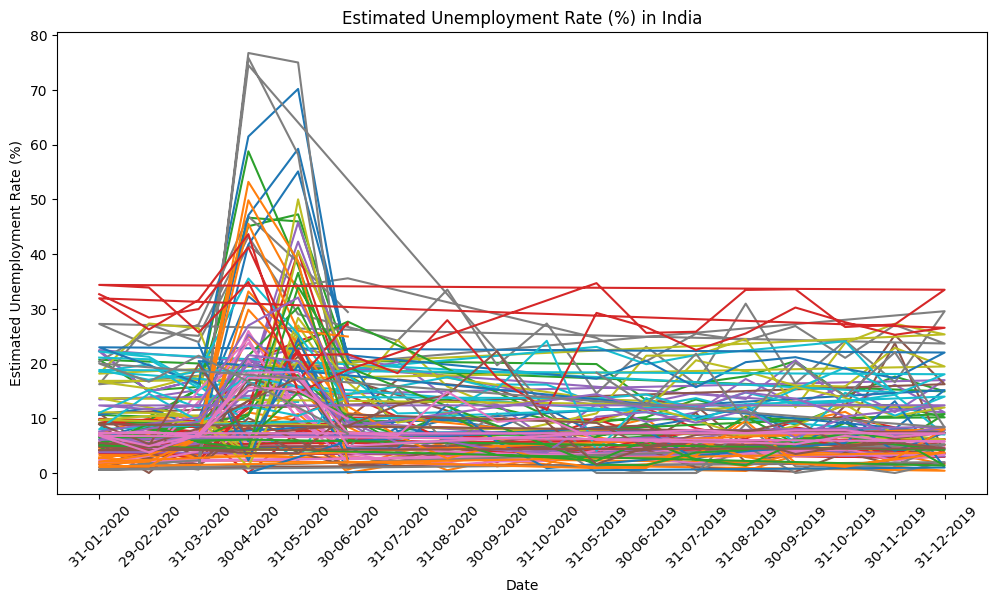

In [ ]:
plt.figure(figsize=(12, 6))

regions = unemployement_in_india['Region'].unique()

for region in regions:
  region_data = unemployement_in_india[unemployement_in_india['Region']==region]

  plt.plot(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], label=region)

plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in India')

plt.show()


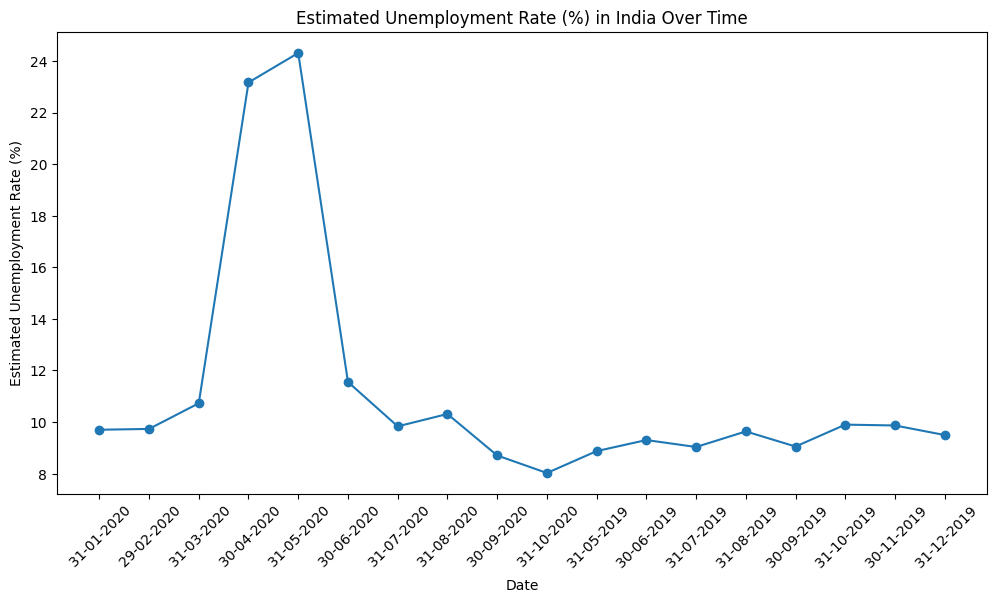

In [ ]:
plt.figure(figsize=(12, 6))

df1_dates = unemployement_in_india['Date'].unique()
df1_mean = pd.DataFrame()
est = []

for date in df1_dates:
  y = unemployement_in_india[unemployement_in_india['Date']==date]
  df1_mean['Date'] = df1_dates
  est.append(y['Estimated Unemployment Rate (%)'].mean())

df1_mean['Estimated Unemployment Rate (%)'] = est
plt.plot(df1_mean['Date'], df1_mean['Estimated Unemployment Rate (%)'], '-o')

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in India Over Time')

plt.show()

As shown in the graph above, the **Estimated Unemployment Rate** in India remained relatively stable until **31 March 2020**. Around this time, the COVID-19 pandemic began to have a significant global impact. In **March 2020**, the **World Health Organization (WHO)** officially declared the COVID-19 outbreak a pandemic. Following this declaration, the unemployment rate in India increased noticeably, suggesting a strong relationship between the pandemic and rising unemployment.

**Reference:** https://www.nm.org/healthbeat/medical-advances/new-therapies-and-drug-trials/covid-19-pandemic-timeline


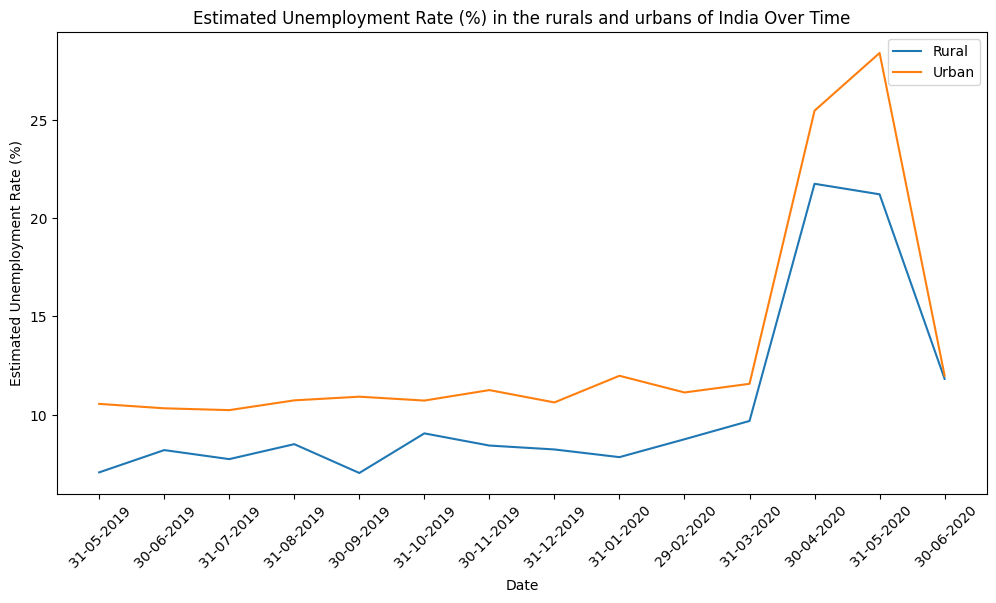

In [ ]:
areas = df1['Area'].unique()
#print(areas)

plt.figure(figsize=(12, 6))
for area in areas:
  y=[]
  x = df1[df1['Area']==area]

  for date in df1_dates:
    y.append(x[x['Date']==date]['Estimated Unemployment Rate (%)'].mean())

  plt.plot(x['Date'].unique(), y, label=area)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in the rurals and urbans of India Over Time')

plt.legend()
plt.show()




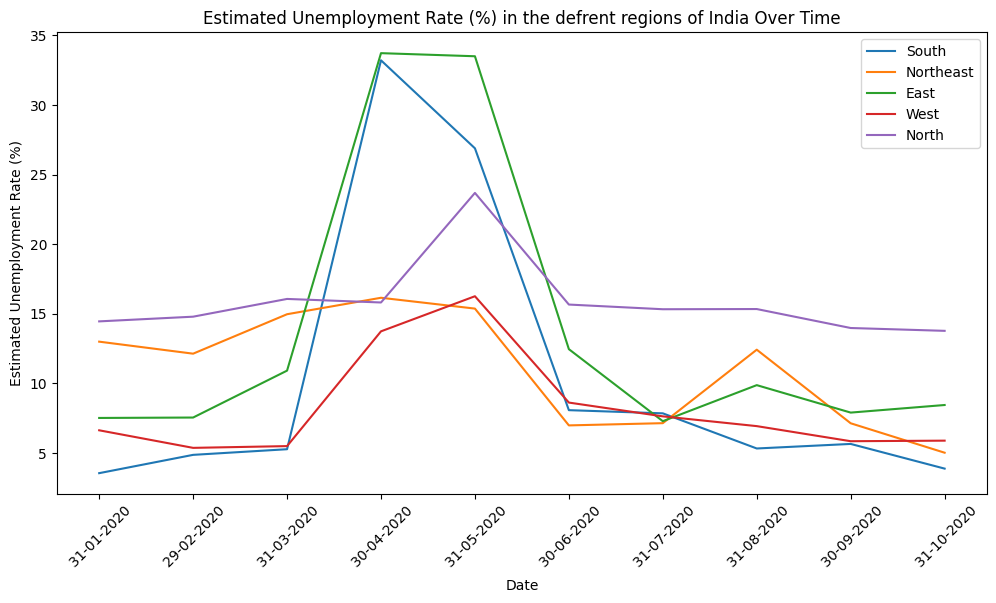

In [ ]:
plt.figure(figsize=(12, 6))

df_dates = df['Date'].unique()
locations = df['Location'].unique()

for location in locations:
  y=[]
  x = df[df['Location']==location]

  for date in df_dates:
    y.append(x[x['Date']==date]['Estimated Unemployment Rate (%)'].mean())

  plt.plot(df_dates, y, label=location)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in the defrent regions of India Over Time')

plt.legend()
plt.show()


